In [2]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import matplotlib.pyplot as plt

In [6]:
pip install numpy pandas scikit-learn matplotlib

     ---------------------------------------- 9.9/9.9 MB 13.7 MB/s eta 0:00:00
     ---------------------------------------- 8.1/8.1 MB 14.8 MB/s eta 0:00:00
     ---------------------------------------- 8.1/8.1 MB 15.3 MB/s eta 0:00:00
     ------------------------------------- 348.5/348.5 kB 21.1 MB/s eta 0:00:00
     --------------------------------------- 36.4/36.4 MB 11.5 MB/s eta 0:00:00
     ------------------------------------- 309.1/309.1 kB 19.9 MB/s eta 0:00:00
  Using cached threadpoolctl-3.6.0-py3-none-any.whl (18 kB)
     ---------------------------------------- 225.2/225.2 kB ? eta 0:00:00
  Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
     ---------------------------------------- 2.3/2.3 MB 29.8 MB/s eta 0:00:00
     ---------------------------------------- 73.8/73.8 kB 4.2 MB/s eta 0:00:00
     ---------------------------------------- 7.0/7.0 MB 15.0 MB/s eta 0:00:00
     -------------------------------------- 122.8/122.8 kB 7.5 MB/s eta 0:00:00
Note: you may n


[notice] A new release of pip available: 22.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [8]:
import numpy as np

In [9]:
# Load your dataset
df = pd.read_csv("EMG-data.csv")

# Remove unmarked data (class 0)
df = df[df["class"] != 0]

df.head()

,time,channel1,channel2,channel3,channel4,channel5,channel6,channel7,channel8,class,label
2287,2400,-0.00001,0.00000,-0.00001,0.00000,0.00000,-0.00001,-0.00001,0.00001,1,1
2288,2401,-0.00001,-0.00002,0.00000,-0.00001,-0.00001,-0.00001,-0.00003,-0.00002,1,1
2289,2402,-0.00001,-0.00002,0.00000,-0.00001,-0.00001,-0.00001,-0.00003,-0.00002,1,1
2290,2403,-0.00001,-0.00002,0.00000,-0.00001,-0.00001,-0.00001,-0.00003,-0.00002,1,1
2291,2404,-0.00001,-0.00002,0.00000,-0.00001,-0.00001,-0.00001,-0.00003,-0.00002,1,1


In [10]:
WINDOW_SIZE = 200
STEP_SIZE = 100  # 50% overlap

signals = df[[f"channel{i}" for i in range(1,9)]].values
labels = df["class"].values

windows = []
window_labels = []

for start in range(0, len(signals) - WINDOW_SIZE, STEP_SIZE):
    end = start + WINDOW_SIZE
    window = signals[start:end]
    label = labels[start:end]
    
    # Assign majority label in the window
    majority_label = np.bincount(label).argmax()
    
    windows.append(window)
    window_labels.append(majority_label)

windows = np.array(windows)
window_labels = np.array(window_labels)

print("Total windows:", len(windows))

Total windows: 15126


In [11]:
def extract_features(window):
    features = []
    
    for ch in range(window.shape[1]):
        signal = window[:, ch]
        
        mav = np.mean(np.abs(signal))
        rms = np.sqrt(np.mean(signal**2))
        var = np.var(signal)
        wl = np.sum(np.abs(np.diff(signal)))
        
        features.extend([mav, rms, var, wl])
        
    return features

X = np.array([extract_features(w) for w in windows])
y = window_labels

print("Feature shape:", X.shape)

Feature shape: (15126, 32)


In [12]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [13]:
df

,time,channel1,channel2,channel3,channel4,channel5,channel6,channel7,channel8,class,label
2287,2400,-0.00001,0.00000,-0.00001,0.00000,0.00000,-0.00001,-0.00001,0.00001,1,1
2288,2401,-0.00001,-0.00002,0.00000,-0.00001,-0.00001,-0.00001,-0.00003,-0.00002,1,1
2289,2402,-0.00001,-0.00002,0.00000,-0.00001,-0.00001,-0.00001,-0.00003,-0.00002,1,1
2290,2403,-0.00001,-0.00002,0.00000,-0.00001,-0.00001,-0.00001,-0.00003,-0.00002,1,1
2291,2404,-0.00001,-0.00002,0.00000,-0.00001,-0.00001,-0.00001,-0.00003,-0.00002,1,1
...,...,...,...,...,...,...,...,...,...,...,...
4237207,50226,0.00009,0.00001,0.00003,0.00001,-0.00003,-0.00008,0.00004,0.00000,6,36
4237208,50227,0.00009,0.00001,0.00003,0.00001,-0.00003,-0.00008,0.00004,0.00000,6,36
4237209,50228,0.00009,0.00001,0.00003,0.00001,-0.00003,-0.00008,0.00004,0.00000,6,36
4237210,50229,0.00014,0.00003,-0.00001,0.00001,-0.00012,0.00006,-0.00007,-0.00013,6,36


In [14]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [15]:
svm_model = SVC(kernel="rbf", C=10, gamma="scale")

svm_model.fit(X_train, y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",10
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [16]:
y_pred = svm_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Accuracy: 0.9068076668869796

Classification Report:

              precision    recall  f1-score   support

           1       0.97      0.99      0.98       501
           2       0.94      0.95      0.95       487
           3       0.87      0.85      0.86       498
           4       0.89      0.89      0.89       506
           5       0.90      0.87      0.89       501
           6       0.87      0.90      0.88       506
           7       0.96      0.85      0.90        27

    accuracy                           0.91      3026
   macro avg       0.91      0.90      0.91      3026
weighted avg       0.91      0.91      0.91      3026



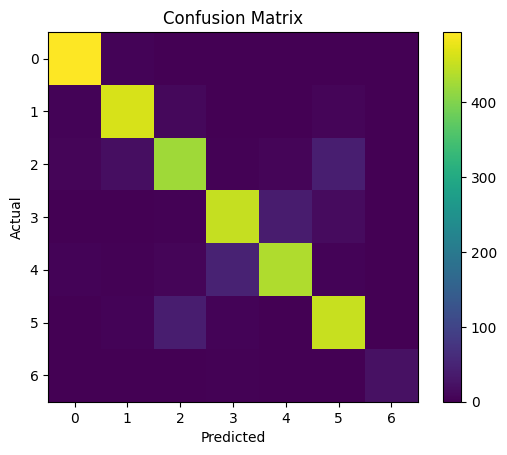

In [17]:
cm = confusion_matrix(y_test, y_pred)

plt.figure()
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.colorbar()
plt.show()

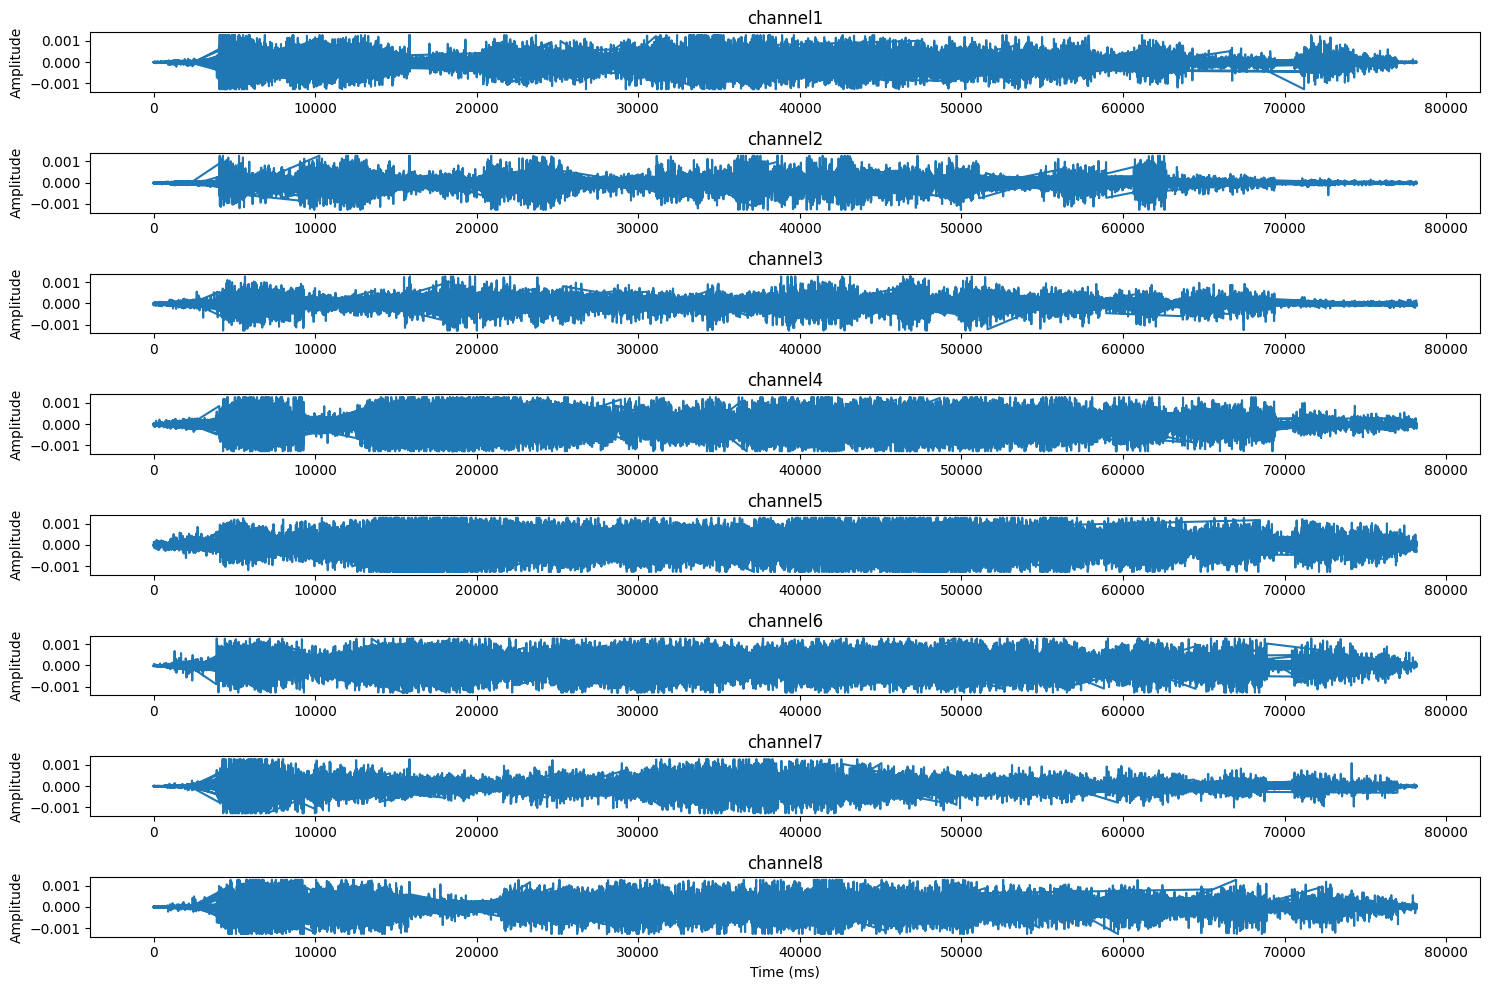

In [18]:
channels = [f"channel{i}" for i in range(1, 9)]

plt.figure(figsize=(15,10))

for i, ch in enumerate(channels):
    plt.subplot(8,1,i+1)
    plt.plot(df["time"], df[ch])
    plt.title(ch)
    plt.ylabel("Amplitude")

plt.xlabel("Time (ms)")
plt.tight_layout()
plt.show()

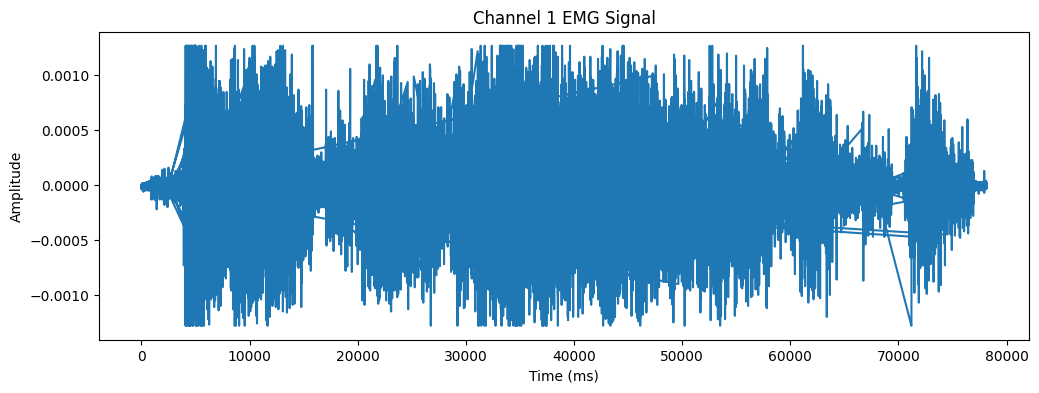

In [19]:
plt.figure(figsize=(12,4))
plt.plot(df["time"], df["channel1"])
plt.title("Channel 1 EMG Signal")
plt.xlabel("Time (ms)")
plt.ylabel("Amplitude")
plt.show()

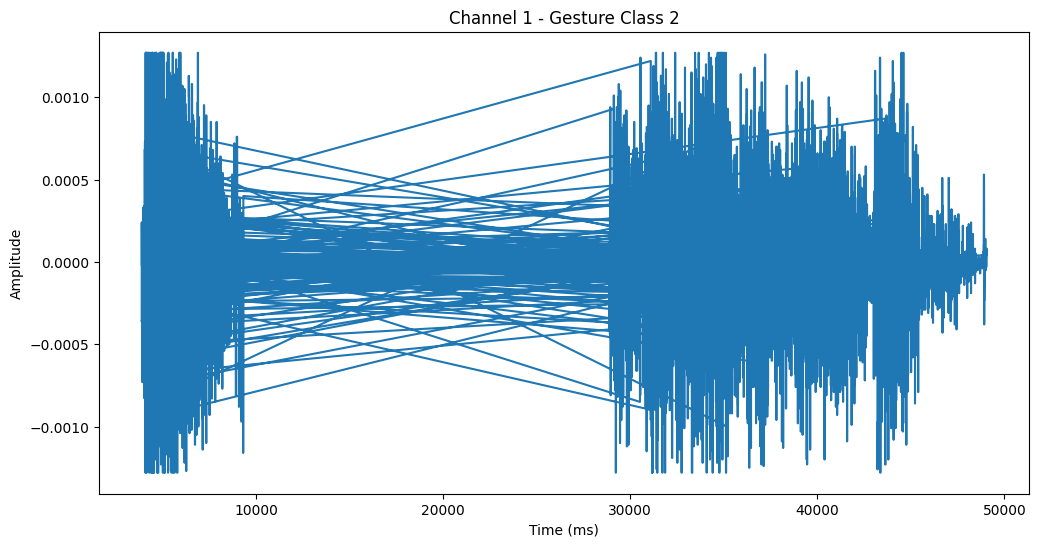

In [20]:
gesture_class = 2

gesture_data = df[df["class"] == gesture_class]

plt.figure(figsize=(12,6))
plt.plot(gesture_data["time"], gesture_data["channel1"])
plt.title(f"Channel 1 - Gesture Class {gesture_class}")
plt.xlabel("Time (ms)")
plt.ylabel("Amplitude")
plt.show()

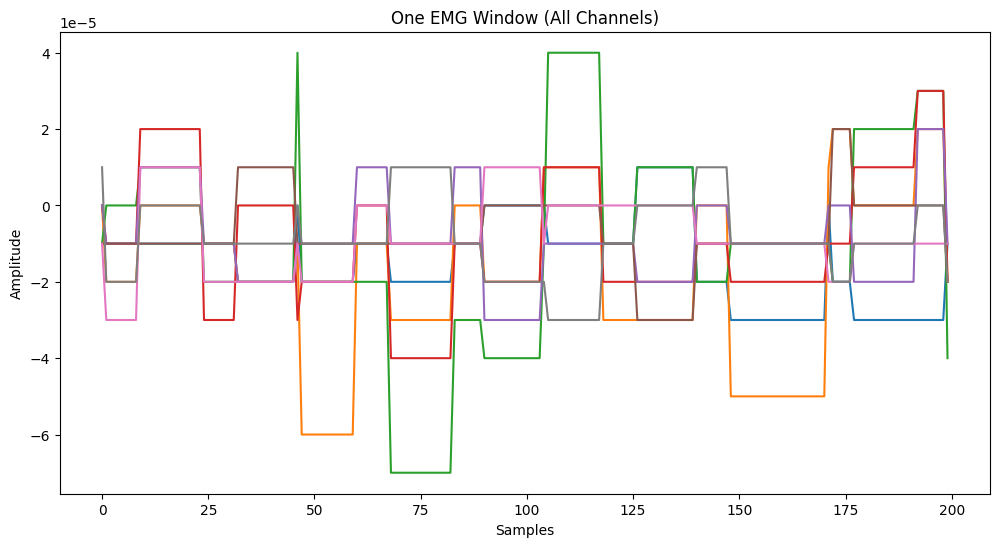

In [21]:
sample_window = windows[0]  # first window

plt.figure(figsize=(12,6))

for i in range(8):
    plt.plot(sample_window[:, i])

plt.title("One EMG Window (All Channels)")
plt.xlabel("Samples")
plt.ylabel("Amplitude")
plt.show()

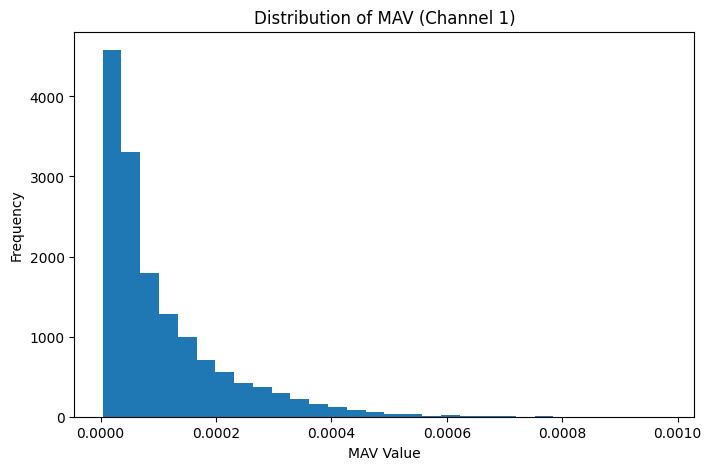

In [22]:
mav_feature_index = 0  # first feature (channel1 MAV)

plt.figure(figsize=(8,5))
plt.hist(X[:, mav_feature_index], bins=30)
plt.title("Distribution of MAV (Channel 1)")
plt.xlabel("MAV Value")
plt.ylabel("Frequency")
plt.show()

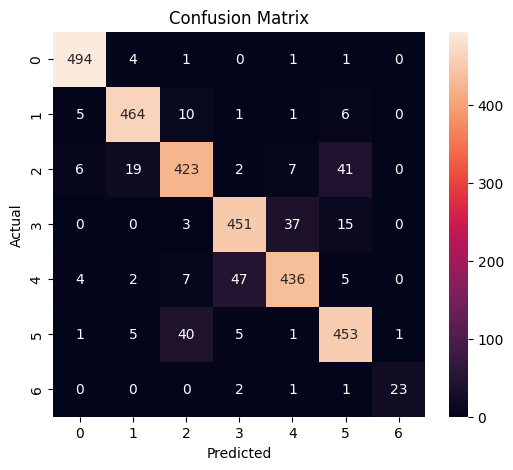

In [25]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

C:\Users\aarya\AppData\Roaming\Python\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


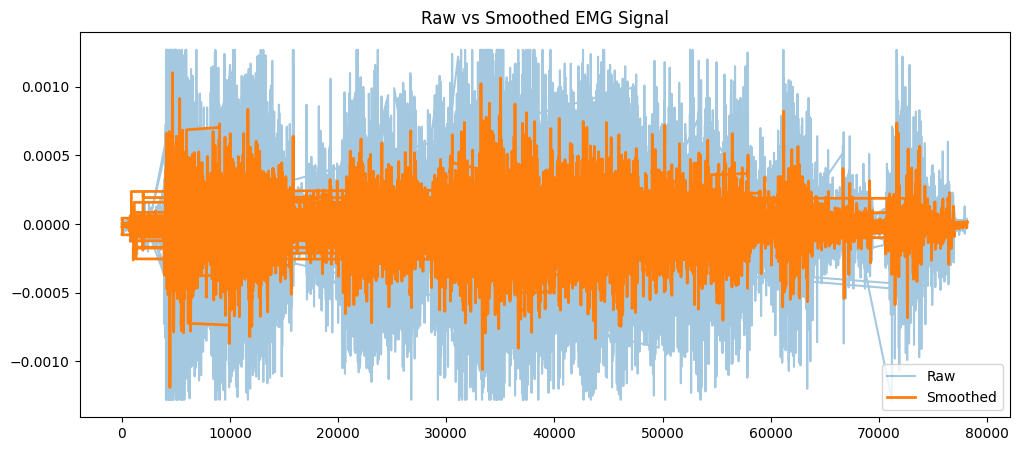

In [26]:
df["channel1_smooth"] = df["channel1"].rolling(window=50).mean()

plt.figure(figsize=(12,5))
plt.plot(df["time"], df["channel1"], alpha=0.4, label="Raw")
plt.plot(df["time"], df["channel1_smooth"], label="Smoothed", linewidth=2)
plt.legend()
plt.title("Raw vs Smoothed EMG Signal")
plt.show()

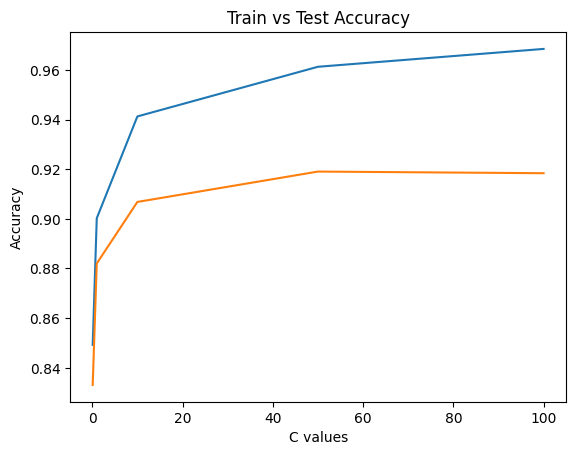

In [27]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import numpy as np

C_values = [0.1, 1, 10, 50, 100]

train_acc = []
test_acc = []

for c in C_values:
    model = SVC(kernel='rbf', C=c, gamma='scale')
    model.fit(X_train, y_train)
    
    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)
    
    train_acc.append(accuracy_score(y_train, train_pred))
    test_acc.append(accuracy_score(y_test, test_pred))

plt.figure()
plt.plot(C_values, train_acc)
plt.plot(C_values, test_acc)
plt.xlabel("C values")
plt.ylabel("Accuracy")
plt.title("Train vs Test Accuracy")
plt.show()

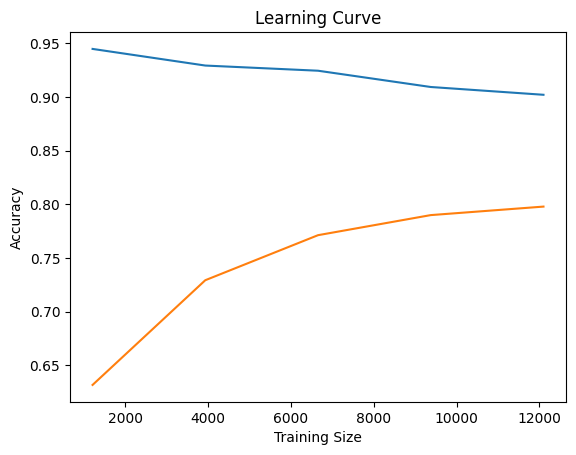

In [28]:
from sklearn.model_selection import learning_curve

train_sizes, train_scores, test_scores = learning_curve(
    SVC(kernel='rbf', C=10, gamma='scale'),
    X,
    y,
    cv=5,
    train_sizes=np.linspace(0.1, 1.0, 5)
)

train_mean = np.mean(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)

plt.figure()
plt.plot(train_sizes, train_mean)
plt.plot(train_sizes, test_mean)
plt.xlabel("Training Size")
plt.ylabel("Accuracy")
plt.title("Learning Curve")
plt.show()

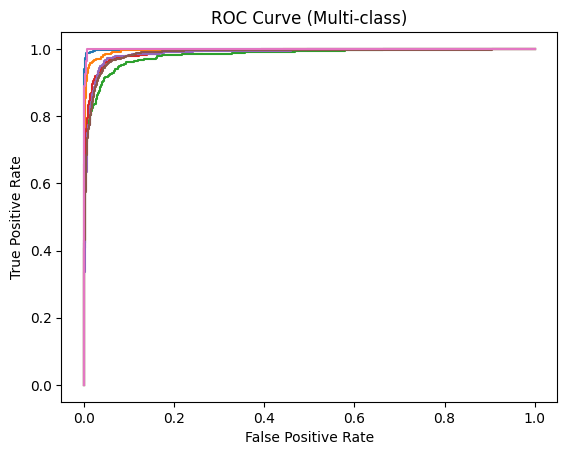

In [29]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
from sklearn.multiclass import OneVsRestClassifier

# Binarize labels
classes = np.unique(y)
y_bin = label_binarize(y_test, classes=classes)

# Train SVM with probability
svm_auc = OneVsRestClassifier(
    SVC(kernel='rbf', C=10, gamma='scale', probability=True)
)

svm_auc.fit(X_train, y_train)

y_score = svm_auc.predict_proba(X_test)

plt.figure()

for i in range(len(classes)):
    fpr, tpr, _ = roc_curve(y_bin[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Multi-class)")
plt.show()

In [1]:
for i in range(len(classes)):
    fpr, tpr, _ = roc_curve(y_bin[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)
    print(f"Class {classes[i]} AUC: {roc_auc:.4f}")

NameError: name 'classes' is not defined

In [2]:
import pandas as pd

In [3]:
df= pd.read_csv("EMG-data.csv")

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4237907 entries, 0 to 4237906
Data columns (total 11 columns):
 #   Column    Dtype  
---  ------    -----  
 0   time      int64  
 1   channel1  float64
 2   channel2  float64
 3   channel3  float64
 4   channel4  float64
 5   channel5  float64
 6   channel6  float64
 7   channel7  float64
 8   channel8  float64
 9   class     int64  
 10  label     int64  
dtypes: float64(8), int64(3)
memory usage: 355.7 MB


In [ ]:
df.dtypes

In [7]:
df['label'].nunique()

36

In [6]:
df['class'].value_counts()

class
0    2725157
6     253009
5     251733
4     251570
1     250055
3     249494
2     243193
7      13696
Name: count, dtype: int64

In [8]:
df['time'].diff().mean()

np.float64(0.01202598641876436)